In [1]:
!pip install kaggle
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [2]:
!kaggle datasets download -d karaagroaiprojects/cadi-ai -p /content --unzip

Dataset URL: https://www.kaggle.com/datasets/karaagroaiprojects/cadi-ai
License(s): GNU Affero General Public License 3.0


In [3]:
#%% [code]
# Imports and dependencies
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import timm  # pip install timm
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
import itertools
import time

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [4]:
#%% [code]
# Custom dataset class to load images and extract labels from YOLO annotation files.
class CashewDataset(Dataset):
    def __init__(self, images_dir, labels_dir, transform=None):
        """
        Args:
            images_dir (str): Directory with images.
            labels_dir (str): Directory with corresponding YOLO-format label files.
            transform (callable, optional): Optional transform to be applied on an image.
        """
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.transform = transform

        # List image files (assuming images have extensions like .jpg or .png)
        self.image_files = [f for f in os.listdir(images_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
        self.image_files.sort()  # Ensure a consistent order

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_filename = self.image_files[idx]
        img_path = os.path.join(self.images_dir, img_filename)
        # Open image
        image = Image.open(img_path).convert("RGB")

        # Apply transformation if provided
        if self.transform:
            image = self.transform(image)

        # Assume the label file has the same basename with .txt extension.
        label_filename = os.path.splitext(img_filename)[0] + ".txt"
        label_path = os.path.join(self.labels_dir, label_filename)
        # Read the file and extract the first class label (as an integer).
        # YOLO file lines: "class x_center y_center width height"
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                lines = f.readlines()
            if len(lines) > 0:
                # Pick the first annotation's class index (as int)
                label = int(lines[0].split()[0])
            else:
                label = 0  # default label if file is empty (adjust as needed)
        else:
            label = 0  # default label if file not found

        return image, label


In [5]:
#%% [code]
# Define data transforms and directories.
# Resize images to 224x224 (GhostNet standard input size) and apply normalization.
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
}

# Update these paths according to your dataset structure in Colab.
train_images_dir = "/content/Data/train/train/images"
train_labels_dir = "/content/Data/train/train/labels"
val_images_dir = "/content/Data/val/val/images"
val_labels_dir = "/content/Data/val/val/labels"

# Create datasets and loaders.
train_dataset = CashewDataset(train_images_dir, train_labels_dir, transform=data_transforms['train'])
val_dataset   = CashewDataset(val_images_dir, val_labels_dir, transform=data_transforms['val'])

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Train samples: {len(train_dataset)}, Validation samples: {len(val_dataset)}")


Train samples: 2721, Validation samples: 525


In [6]:
#%% [code]
# Create the GhostNet model using timm.
# 'ghostnet_100' is a variant; ensure you have the right model name from timm.
num_classes = 3  # ['abiotic', 'insect', 'disease']
model = timm.create_model('ghostnet_100', pretrained=True, num_classes=num_classes)
model.to(device)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/20.9M [00:00<?, ?B/s]

GhostNet(
  (conv_stem): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act1): ReLU(inplace=True)
  (blocks): Sequential(
    (0): Sequential(
      (0): GhostBottleneck(
        (ghost1): GhostModule(
          (primary_conv): Sequential(
            (0): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (cheap_operation): Sequential(
            (0): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=8, bias=False)
            (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
        )
        (ghost2): GhostModule(
          (primary_conv): Sequential(
            (0): Conv2d(16, 8, kernel_size=(1, 1)

In [7]:
#%% [code]
# Define loss function and optimizer.
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)


In [8]:
#%% [code]
# Training loop with metric calculations.
num_epochs = 10  # You can increase the number of epochs.
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

# For overall metric calculations on validation set.
all_val_labels = []
all_val_preds = []

for epoch in range(num_epochs):
    start_time = time.time()
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    # Validation
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    epoch_val_labels = []
    epoch_val_preds = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

            epoch_val_labels.extend(labels.cpu().numpy())
            epoch_val_preds.extend(preds.cpu().numpy())

    epoch_val_loss = val_loss / total_val
    epoch_val_acc = correct_val / total_val
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    all_val_labels.extend(epoch_val_labels)
    all_val_preds.extend(epoch_val_preds)

    elapsed = time.time() - start_time
    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f} | "
          f"Time: {elapsed:.2f}s")

# Calculate overall metrics on validation set.
val_acc = accuracy_score(all_val_labels, all_val_preds)
val_precision = precision_score(all_val_labels, all_val_preds, average='macro', zero_division=0)
val_recall = recall_score(all_val_labels, all_val_preds, average='macro', zero_division=0)
val_f1 = f1_score(all_val_labels, all_val_preds, average='macro', zero_division=0)
cm = confusion_matrix(all_val_labels, all_val_preds)

print("\nValidation Metrics:")
print("Accuracy: {:.4f}".format(val_acc))
print("Precision: {:.4f}".format(val_precision))
print("Recall: {:.4f}".format(val_recall))
print("F1 Score: {:.4f}".format(val_f1))


Epoch 1/10 | Train Loss: 0.9275 Acc: 0.5623 | Val Loss: 0.7655 Acc: 0.6686 | Time: 162.67s
Epoch 2/10 | Train Loss: 0.6775 Acc: 0.7016 | Val Loss: 0.6191 Acc: 0.7390 | Time: 159.77s
Epoch 3/10 | Train Loss: 0.5080 Acc: 0.7957 | Val Loss: 0.5521 Acc: 0.7695 | Time: 159.91s
Epoch 4/10 | Train Loss: 0.3437 Acc: 0.8651 | Val Loss: 0.5523 Acc: 0.7733 | Time: 158.87s
Epoch 5/10 | Train Loss: 0.2420 Acc: 0.9147 | Val Loss: 0.6308 Acc: 0.7714 | Time: 161.80s
Epoch 6/10 | Train Loss: 0.1763 Acc: 0.9379 | Val Loss: 0.7470 Acc: 0.7619 | Time: 160.82s
Epoch 7/10 | Train Loss: 0.1300 Acc: 0.9559 | Val Loss: 0.7847 Acc: 0.7733 | Time: 157.95s
Epoch 8/10 | Train Loss: 0.1033 Acc: 0.9647 | Val Loss: 0.8232 Acc: 0.7505 | Time: 158.69s
Epoch 9/10 | Train Loss: 0.0715 Acc: 0.9739 | Val Loss: 0.9707 Acc: 0.7524 | Time: 158.49s
Epoch 10/10 | Train Loss: 0.0815 Acc: 0.9721 | Val Loss: 0.9581 Acc: 0.7752 | Time: 158.78s

Validation Metrics:
Accuracy: 0.7535
Precision: 0.7402
Recall: 0.7327
F1 Score: 0.7356


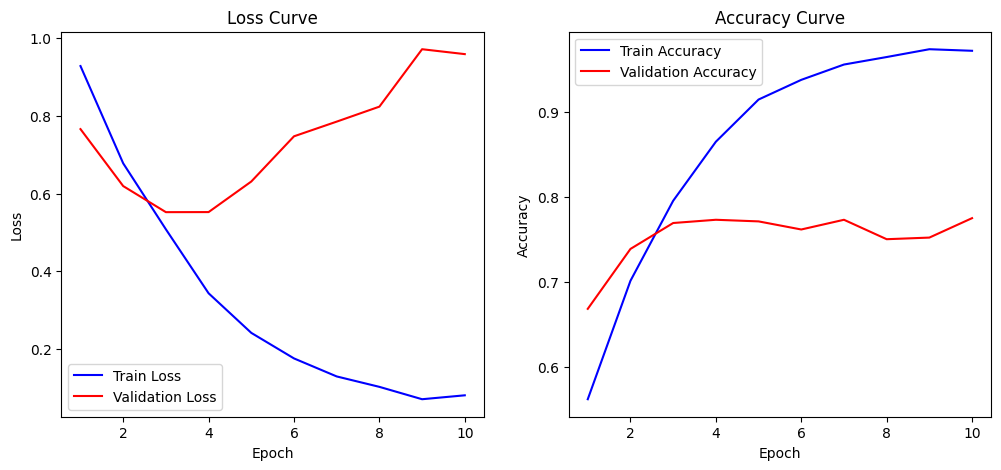

In [9]:
#%% [code]
# Plot training and validation loss and accuracy curves.
epochs = range(1, num_epochs+1)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, 'b-', label='Train Loss')
plt.plot(epochs, val_losses, 'r-', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, 'b-', label='Train Accuracy')
plt.plot(epochs, val_accuracies, 'r-', label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.show()


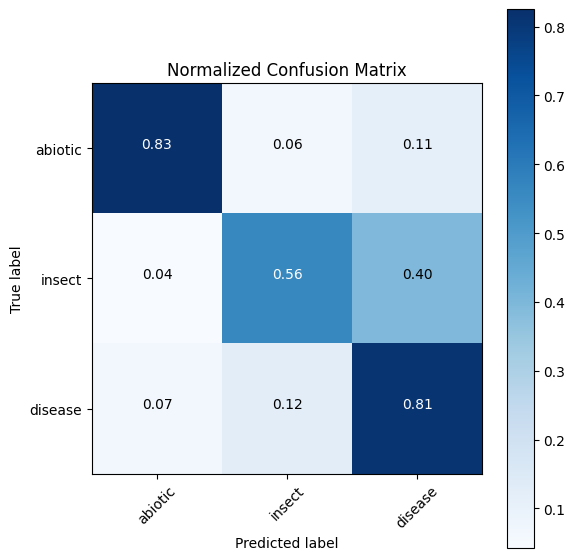

In [10]:
#%% [code]
# Plot the confusion matrix.
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(6, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()

class_names = ['abiotic', 'insect', 'disease']
plot_confusion_matrix(cm, classes=class_names, normalize=True,
                      title='Normalized Confusion Matrix')
plt.show()
